In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

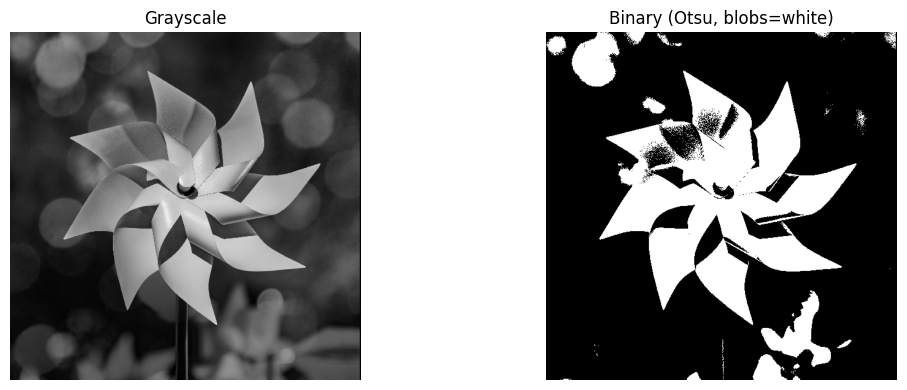

In [18]:
image_path = '../../edge_detection.png'
image_color = cv2.imread(image_path)

# Fallback: synthetic non-overlapping blobs if no input
if image_color is None:
    H, W = 256, 256
    image_color = np.zeros((H, W, 3), dtype=np.uint8)
    centers = [(64, 64), (64, 192), (192, 64), (192, 192), (128, 128)]
    radii = [25, 20, 30, 22, 28]
    intensities = [60, 120, 180, 90, 200]
    for (cy, cx), r, val in zip(centers, radii, intensities):
        cv2.circle(image_color, (cx, cy), r, (val, val, val), -1)

image = cv2.cvtColor(image_color, cv2.COLOR_BGR2GRAY)

# Otsu to get binary blobs
_, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Ensure blobs are white (foreground). If most of the image is white, invert.
H, W = image.shape
white_ratio = np.count_nonzero(binary) / float(H * W)
if white_ratio > 0.5:
    binary = 255 - binary

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title('Grayscale')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(binary, cmap='gray')
plt.title('Binary (Otsu, blobs=white)')
plt.axis('off')
plt.tight_layout()
plt.show()

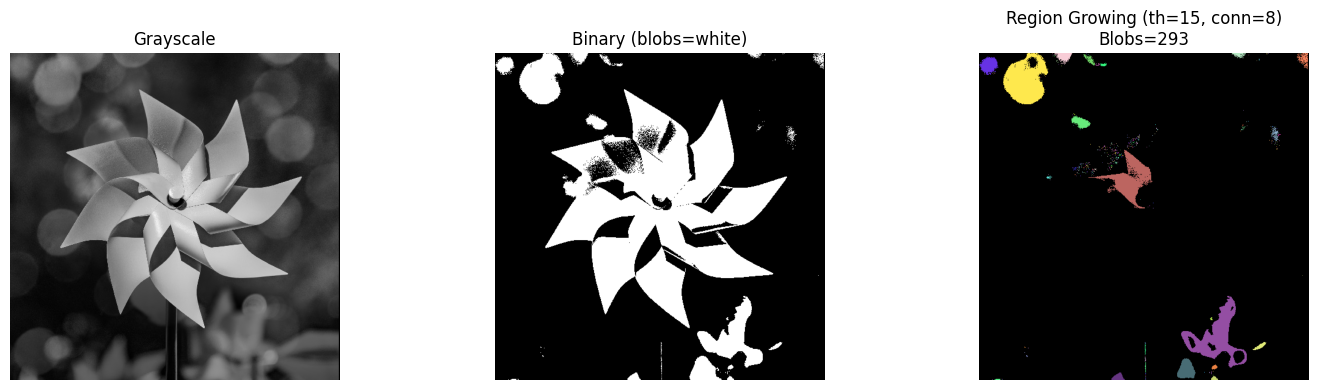

In [19]:
from collections import deque

def region_growing(image: np.ndarray, seed: tuple[int, int], threshold: int = 15, connectivity: int = 8, allow_mask: np.ndarray | None = None):
    H, W = image.shape
    segmented = np.zeros((H, W), dtype=np.uint8)
    visited = np.zeros((H, W), dtype=bool)

    q = deque([seed])
    seed_value = int(image[seed])

    if connectivity == 8:
        neighbors = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]
    else:
        neighbors = [(-1,0), (1,0), (0,-1), (0,1)]

    while q:
        y, x = q.popleft()
        if y < 0 or y >= H or x < 0 or x >= W or visited[y, x]:
            continue
        if allow_mask is not None and allow_mask[y, x] == 0:
            continue
        if abs(int(image[y, x]) - seed_value) <= threshold:
            visited[y, x] = True
            segmented[y, x] = 255
            for dy, dx in neighbors:
                q.append((y + dy, x + dx))
    return segmented


def auto_region_growing_all_blobs(gray: np.ndarray, binmask: np.ndarray, threshold: int = 15, connectivity: int = 8):
    """
    Use connected components of binmask (blobs=white) to pick a seed inside each CC,
    then grow within that CC using intensity tolerance.
    """
    num, labels = cv2.connectedComponents(binmask)

    H, W = gray.shape
    out_labels = np.zeros((H, W), dtype=np.int32)
    next_label = 1

    for comp_id in range(1, num):
        ys, xs = np.where(labels == comp_id)
        if ys.size == 0:
            continue
        cy = int(np.mean(ys))
        cx = int(np.mean(xs))
        # Ensure seed is inside the component
        if labels[cy, cx] != comp_id:
            cy, cx = int(ys[0]), int(xs[0])

        grown = region_growing(gray, (cy, cx), threshold=threshold, connectivity=connectivity, allow_mask=(labels == comp_id).astype(np.uint8))
        mask = (grown > 0)
        out_labels[mask] = next_label
        next_label += 1

    return out_labels


# Parameters
th = 15
conn = 8
labels = auto_region_growing_all_blobs(image, binary, threshold=th, connectivity=conn)

# Colorize labels for visualization
label_ids = np.unique(labels)
label_ids = label_ids[label_ids != 0]
color_vis = np.zeros((*labels.shape, 3), dtype=np.uint8)
for lid in label_ids:
    col = np.random.default_rng(lid).integers(50, 255, size=3, dtype=np.uint8)
    color_vis[labels == lid] = col

plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title('Grayscale')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(binary, cmap='gray')
plt.title('Binary (blobs=white)')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(color_vis)
plt.title(f'Region Growing (th={th}, conn={conn})\nBlobs={len(label_ids)}')
plt.axis('off')
plt.tight_layout()
plt.show()

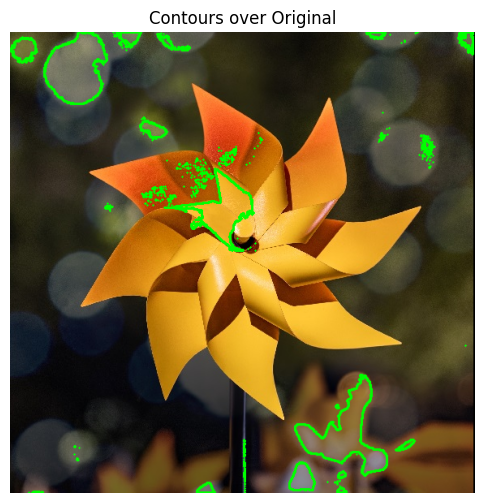

In [20]:
# Draw contours per labeled region using the binary mask for accuracy
vis_contours = image_color.copy()
for lid in label_ids:
    region_mask = (labels == lid).astype(np.uint8) * 255
    contours, _ = cv2.findContours(region_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(vis_contours, contours, -1, (0, 255, 0), 2)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(vis_contours, cv2.COLOR_BGR2RGB))
plt.title('Contours over Original')
plt.axis('off')
plt.show()